<a href="https://colab.research.google.com/github/djtheconqueror/home_ai/blob/main/Operational_Biosecurity_Readiness_AI_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Operational Biosecurity & Readiness Dashboard v1

This project is an applied AI prototype focused on combining human readiness, environmental context, and biosignal risk indicators to estimate operational readiness and biosecurity risk.

The goal is to explore how geographic, biological, environmental, and performance-related signals can be translated into clearer decision support for health, readiness, and risk assessment.

In [1]:
!pip install scikit-learn pandas numpy matplotlib joblib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [2]:
rng = np.random.default_rng(42)
n = 1000

locations = [
    "Boston, MA",
    "Miami, FL",
    "Dallas, TX",
    "Seattle, WA",
    "Phoenix, AZ",
    "Atlanta, GA",
]

data = pd.DataFrame({
    "location": rng.choice(locations, n),

    # Environmental / geographic signals
    "temperature_f": rng.uniform(35, 105, n),
    "humidity": rng.uniform(0.20, 0.95, n),
    "air_quality_index": rng.uniform(10, 180, n),
    "population_density": rng.uniform(500, 12000, n),
    "local_disease_trend": rng.uniform(0, 1, n),

    # Human readiness signals
    "sleep_hours": rng.uniform(3, 10, n),
    "stress_score": rng.uniform(0, 1, n),
    "hydration_score": rng.uniform(0, 1, n),
    "training_load": rng.uniform(0, 1, n),
    "cognitive_fatigue": rng.uniform(0, 1, n),

    # Biosignal / biosecurity-style signals
    "biosignal_anomaly": rng.uniform(0, 1, n),
    "detection_confidence": rng.uniform(0, 1, n),
    "signal_persistence": rng.uniform(0, 1, n),
})

data.head()

,location,temperature_f,humidity,air_quality_index,population_density,local_disease_trend,sleep_hours,stress_score,hydration_score,training_load,cognitive_fatigue,biosignal_anomaly,detection_confidence,signal_persistence
0,"Boston, MA",86.569398,0.703891,15.759225,5261.317195,0.018852,4.198435,0.914842,0.501541,0.018285,0.690855,0.365929,0.518850,0.736110
1,"Phoenix, AZ",97.048202,0.920440,126.112543,7060.855259,0.455022,6.547789,0.326989,0.732395,0.777633,0.636528,0.052236,0.519971,0.080359
2,"Seattle, WA",99.474004,0.478184,171.584366,507.386493,0.618074,3.789012,0.579260,0.188225,0.161936,0.631145,0.171039,0.470237,0.242714
3,"Dallas, TX",70.254305,0.518811,150.955583,7916.040819,0.460396,7.382342,0.877463,0.443791,0.598738,0.206704,0.616554,0.612949,0.885895
4,"Dallas, TX",71.419258,0.809092,57.123684,8759.021609,0.130645,9.124293,0.772995,0.532530,0.681082,0.579347,0.775100,0.885627,0.576921


In [3]:
# Convert raw environmental values into risk-style features

heat_risk = np.clip((data["temperature_f"] - 75) / 35, 0, 1)
humidity_risk = np.clip((data["humidity"] - 0.55) / 0.40, 0, 1)
air_quality_risk = np.clip(data["air_quality_index"] / 180, 0, 1)
density_risk = np.clip(data["population_density"] / 12000, 0, 1)

readiness_risk = (
    0.30 * (1 - data["sleep_hours"] / 10) +
    0.25 * data["stress_score"] +
    0.15 * (1 - data["hydration_score"]) +
    0.15 * data["training_load"] +
    0.15 * data["cognitive_fatigue"]
)

environmental_risk = (
    0.25 * heat_risk +
    0.20 * humidity_risk +
    0.25 * air_quality_risk +
    0.15 * density_risk +
    0.15 * data["local_disease_trend"]
)

biosignal_risk = (
    0.40 * data["biosignal_anomaly"] +
    0.30 * data["detection_confidence"] +
    0.30 * data["signal_persistence"]
)

overall_risk_score = (
    0.35 * readiness_risk +
    0.30 * environmental_risk +
    0.35 * biosignal_risk
)

data["overall_risk_score"] = overall_risk_score

data["operational_status"] = pd.cut(
    data["overall_risk_score"],
    bins=[-0.01, 0.35, 0.55, 0.75, 1.01],
    labels=["READY", "MONITOR", "MITIGATE", "RECOVER"]
)

data.head()

,location,temperature_f,humidity,air_quality_index,population_density,local_disease_trend,sleep_hours,stress_score,hydration_score,training_load,cognitive_fatigue,biosignal_anomaly,detection_confidence,signal_persistence,overall_risk_score,operational_status
0,"Boston, MA",86.569398,0.703891,15.759225,5261.317195,0.018852,4.198435,0.914842,0.501541,0.018285,0.690855,0.365929,0.518850,0.736110,0.462385,MONITOR
1,"Phoenix, AZ",97.048202,0.920440,126.112543,7060.855259,0.455022,6.547789,0.326989,0.732395,0.777633,0.636528,0.052236,0.519971,0.080359,0.425813,MONITOR
2,"Seattle, WA",99.474004,0.478184,171.584366,507.386493,0.618074,3.789012,0.579260,0.188225,0.161936,0.631145,0.171039,0.470237,0.242714,0.452615,MONITOR
3,"Dallas, TX",70.254305,0.518811,150.955583,7916.040819,0.460396,7.382342,0.877463,0.443791,0.598738,0.206704,0.616554,0.612949,0.885895,0.532747,MONITOR
4,"Dallas, TX",71.419258,0.809092,57.123684,8759.021609,0.130645,9.124293,0.772995,0.532530,0.681082,0.579347,0.775100,0.885627,0.576921,0.531019,MONITOR


In [4]:
# Convert location into model-readable columns
model_data = pd.get_dummies(data, columns=["location"], drop_first=False)

feature_cols = [
    col for col in model_data.columns
    if col not in ["overall_risk_score", "operational_status"]
]

X = model_data[feature_cols]
y = model_data["operational_status"]

X.head()

,temperature_f,humidity,air_quality_index,population_density,local_disease_trend,sleep_hours,stress_score,hydration_score,training_load,cognitive_fatigue,biosignal_anomaly,detection_confidence,signal_persistence,"location_Atlanta, GA","location_Boston, MA","location_Dallas, TX","location_Miami, FL","location_Phoenix, AZ","location_Seattle, WA"
0,86.569398,0.703891,15.759225,5261.317195,0.018852,4.198435,0.914842,0.501541,0.018285,0.690855,0.365929,0.518850,0.736110,False,True,False,False,False,False
1,97.048202,0.920440,126.112543,7060.855259,0.455022,6.547789,0.326989,0.732395,0.777633,0.636528,0.052236,0.519971,0.080359,False,False,False,False,True,False
2,99.474004,0.478184,171.584366,507.386493,0.618074,3.789012,0.579260,0.188225,0.161936,0.631145,0.171039,0.470237,0.242714,False,False,False,False,False,True
3,70.254305,0.518811,150.955583,7916.040819,0.460396,7.382342,0.877463,0.443791,0.598738,0.206704,0.616554,0.612949,0.885895,False,False,True,False,False,False
4,71.419258,0.809092,57.123684,8759.021609,0.130645,9.124293,0.772995,0.532530,0.681082,0.579347,0.775100,0.885627,0.576921,False,False,True,False,False,False


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    MITIGATE       1.00      0.05      0.10        20
     MONITOR       0.81      0.99      0.89       156
       READY       0.80      0.33      0.47        24

    accuracy                           0.81       200
   macro avg       0.87      0.46      0.49       200
weighted avg       0.83      0.81      0.76       200



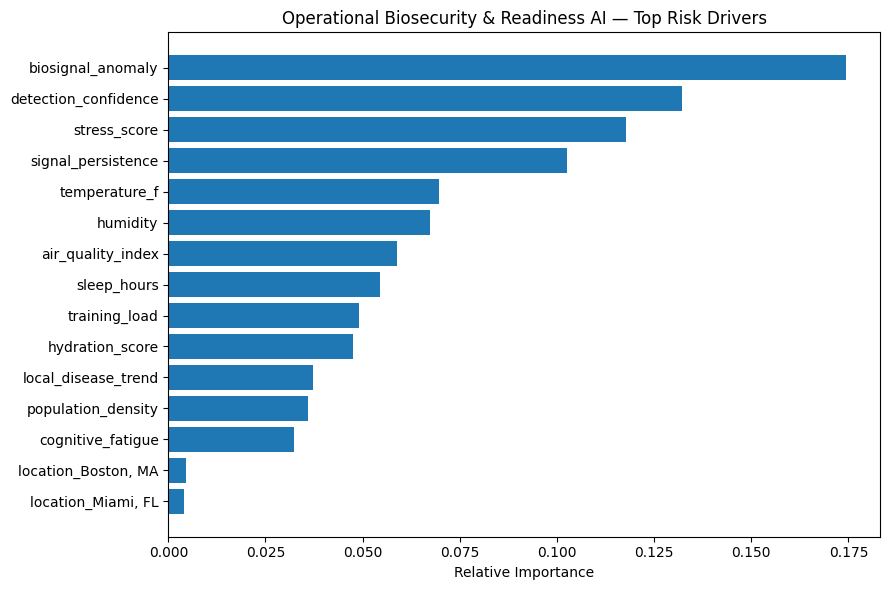

In [6]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=True).tail(15)

plt.figure(figsize=(9, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.title("Operational Biosecurity & Readiness AI — Top Risk Drivers")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

In [7]:
def prepare_operational_sample(sample_dict):
    sample_df = pd.DataFrame([sample_dict])

    sample_encoded = pd.get_dummies(sample_df)

    # Add any missing training columns
    for col in feature_cols:
        if col not in sample_encoded.columns:
            sample_encoded[col] = 0

    # Keep same column order as training
    sample_encoded = sample_encoded[feature_cols]

    return sample_encoded


def calculate_risk_components(sample):
    heat_risk = np.clip((sample["temperature_f"] - 75) / 35, 0, 1)
    humidity_risk = np.clip((sample["humidity"] - 0.55) / 0.40, 0, 1)
    air_quality_risk = np.clip(sample["air_quality_index"] / 180, 0, 1)
    density_risk = np.clip(sample["population_density"] / 12000, 0, 1)

    readiness_risk = (
        0.30 * (1 - sample["sleep_hours"] / 10) +
        0.25 * sample["stress_score"] +
        0.15 * (1 - sample["hydration_score"]) +
        0.15 * sample["training_load"] +
        0.15 * sample["cognitive_fatigue"]
    )

    environmental_risk = (
        0.25 * heat_risk +
        0.20 * humidity_risk +
        0.25 * air_quality_risk +
        0.15 * density_risk +
        0.15 * sample["local_disease_trend"]
    )

    biosignal_risk = (
        0.40 * sample["biosignal_anomaly"] +
        0.30 * sample["detection_confidence"] +
        0.30 * sample["signal_persistence"]
    )

    overall_risk = (
        0.35 * readiness_risk +
        0.30 * environmental_risk +
        0.35 * biosignal_risk
    )

    return {
        "readiness_risk": float(readiness_risk),
        "environmental_risk": float(environmental_risk),
        "biosignal_risk": float(biosignal_risk),
        "overall_risk": float(overall_risk),
    }


def recommendation_from_status(status):
    if status == "READY":
        return "Proceed with normal operations while maintaining routine monitoring."
    elif status == "MONITOR":
        return "Proceed with caution and continue monitoring readiness, environment, and biosignal trends."
    elif status == "MITIGATE":
        return "Reduce operational load, address key risk drivers, and increase monitoring."
    elif status == "RECOVER":
        return "Prioritize recovery, reduce exposure, and reassess before high-demand activity."
    else:
        return "Review inputs and reassess operational status."


def operational_predict(sample_dict):
    x = prepare_operational_sample(sample_dict)

    prediction = model.predict(x)[0]
    probabilities = model.predict_proba(x)[0]
    class_order = model.classes_

    prob_map = {
        cls: float(prob)
        for cls, prob in zip(class_order, probabilities)
    }

    risk_components = calculate_risk_components(sample_dict)

    bullets = []

    if sample_dict["sleep_hours"] < 6:
        bullets.append("Low sleep is increasing readiness risk.")
    if sample_dict["stress_score"] > 0.65:
        bullets.append("High stress is reducing operational readiness.")
    if sample_dict["hydration_score"] < 0.45:
        bullets.append("Low hydration may impair performance.")
    if sample_dict["training_load"] > 0.75:
        bullets.append("High training load may require recovery planning.")
    if sample_dict["cognitive_fatigue"] > 0.65:
        bullets.append("Cognitive fatigue is elevated.")

    if sample_dict["temperature_f"] > 90:
        bullets.append("High temperature is increasing environmental burden.")
    if sample_dict["humidity"] > 0.75:
        bullets.append("High humidity may worsen heat stress.")
    if sample_dict["air_quality_index"] > 100:
        bullets.append("Air quality is a notable environmental risk factor.")
    if sample_dict["local_disease_trend"] > 0.65:
        bullets.append("Local disease trend is elevated.")

    if sample_dict["biosignal_anomaly"] > 0.65:
        bullets.append("Biosignal anomaly is elevated.")
    if sample_dict["detection_confidence"] > 0.70:
        bullets.append("Detection confidence suggests the biosignal should be taken seriously.")
    if sample_dict["signal_persistence"] > 0.65:
        bullets.append("Signal persistence indicates the issue may not be temporary.")

    if not bullets:
        bullets.append("Most readiness, environmental, and biosignal indicators are within acceptable ranges.")

    explanation = {
        "status": prediction,
        "probabilities": prob_map,
        "risk_components": risk_components,
        "recommendation": recommendation_from_status(prediction),
        "bullets": bullets,
        "summary": f"Operational Biosecurity & Readiness AI classifies this profile as {prediction} with an overall risk score of {risk_components['overall_risk']:.1%}."
    }

    return prediction, explanation

In [8]:
sample_operation = {
    "location": "Miami, FL",
    "temperature_f": 94,
    "humidity": 0.82,
    "air_quality_index": 115,
    "population_density": 7200,
    "local_disease_trend": 0.62,

    "sleep_hours": 5.4,
    "stress_score": 0.74,
    "hydration_score": 0.38,
    "training_load": 0.81,
    "cognitive_fatigue": 0.70,

    "biosignal_anomaly": 0.58,
    "detection_confidence": 0.72,
    "signal_persistence": 0.64,
}

status, explanation = operational_predict(sample_operation)

print("=" * 70)
print("OPERATIONAL BIOSECURITY & READINESS REPORT")
print("=" * 70)
print()
print("Status:", explanation["status"])
print("Summary:", explanation["summary"])
print()
print("Risk Components:")
for key, value in explanation["risk_components"].items():
    print(f"- {key}: {value:.1%}")

print()
print("Recommendation:")
print(explanation["recommendation"])

print()
print("Key Drivers:")
for bullet in explanation["bullets"]:
    print("•", bullet)

OPERATIONAL BIOSECURITY & READINESS REPORT

Status: MITIGATE
Summary: Operational Biosecurity & Readiness AI classifies this profile as MITIGATE with an overall risk score of 63.3%.

Risk Components:
- readiness_risk: 64.2%
- environmental_risk: 61.3%
- biosignal_risk: 64.0%
- overall_risk: 63.3%

Recommendation:
Reduce operational load, address key risk drivers, and increase monitoring.

Key Drivers:
• Low sleep is increasing readiness risk.
• High stress is reducing operational readiness.
• Low hydration may impair performance.
• High training load may require recovery planning.
• Cognitive fatigue is elevated.
• High temperature is increasing environmental burden.
• High humidity may worsen heat stress.
• Air quality is a notable environmental risk factor.
• Detection confidence suggests the biosignal should be taken seriously.


In [9]:
operational_scenarios = {
    "Low Risk Training Day": {
        "location": "Seattle, WA",
        "temperature_f": 62,
        "humidity": 0.48,
        "air_quality_index": 35,
        "population_density": 4200,
        "local_disease_trend": 0.18,

        "sleep_hours": 8.1,
        "stress_score": 0.22,
        "hydration_score": 0.84,
        "training_load": 0.38,
        "cognitive_fatigue": 0.24,

        "biosignal_anomaly": 0.16,
        "detection_confidence": 0.25,
        "signal_persistence": 0.20,
    },

    "Heat Stress Environment": {
        "location": "Phoenix, AZ",
        "temperature_f": 101,
        "humidity": 0.31,
        "air_quality_index": 92,
        "population_density": 3400,
        "local_disease_trend": 0.35,

        "sleep_hours": 6.4,
        "stress_score": 0.48,
        "hydration_score": 0.42,
        "training_load": 0.70,
        "cognitive_fatigue": 0.51,

        "biosignal_anomaly": 0.36,
        "detection_confidence": 0.44,
        "signal_persistence": 0.39,
    },

    "Urban Disease Watch": {
        "location": "Boston, MA",
        "temperature_f": 71,
        "humidity": 0.62,
        "air_quality_index": 78,
        "population_density": 9500,
        "local_disease_trend": 0.81,

        "sleep_hours": 6.7,
        "stress_score": 0.55,
        "hydration_score": 0.58,
        "training_load": 0.49,
        "cognitive_fatigue": 0.57,

        "biosignal_anomaly": 0.46,
        "detection_confidence": 0.61,
        "signal_persistence": 0.58,
    },

    "High Biosecurity Concern": {
        "location": "Miami, FL",
        "temperature_f": 93,
        "humidity": 0.84,
        "air_quality_index": 122,
        "population_density": 8200,
        "local_disease_trend": 0.76,

        "sleep_hours": 5.2,
        "stress_score": 0.78,
        "hydration_score": 0.36,
        "training_load": 0.82,
        "cognitive_fatigue": 0.74,

        "biosignal_anomaly": 0.84,
        "detection_confidence": 0.88,
        "signal_persistence": 0.82,
    },
}

In [10]:
def score_operational_scenarios(scenarios):
    rows = []

    for name, sample in scenarios.items():
        status, explanation = operational_predict(sample)
        risks = explanation["risk_components"]

        rows.append({
            "scenario": name,
            "location": sample["location"],
            "status": status,
            "overall_risk": round(risks["overall_risk"], 3),
            "readiness_risk": round(risks["readiness_risk"], 3),
            "environmental_risk": round(risks["environmental_risk"], 3),
            "biosignal_risk": round(risks["biosignal_risk"], 3),
            "recommendation": explanation["recommendation"],
        })

    return pd.DataFrame(rows).sort_values("overall_risk", ascending=False)

scenario_results = score_operational_scenarios(operational_scenarios)
scenario_results

,scenario,location,status,overall_risk,readiness_risk,environmental_risk,biosignal_risk,recommendation
3,High Biosecurity Concern,"Miami, FL",MITIGATE,0.728,0.669,0.660,0.846,"Reduce operational load, address key risk driv..."
2,Urban Disease Watch,"Boston, MA",MONITOR,0.465,0.459,0.384,0.541,Proceed with caution and continue monitoring r...
1,Heat Stress Environment,"Phoenix, AZ",MONITOR,0.434,0.496,0.408,0.393,Proceed with caution and continue monitoring r...
0,Low Risk Training Day,"Seattle, WA",READY,0.188,0.229,0.128,0.199,Proceed with normal operations while maintaini...


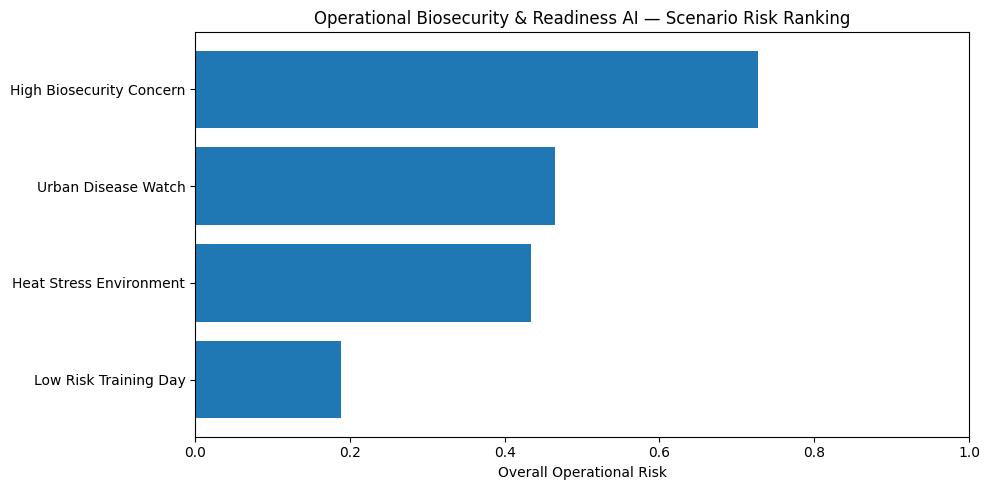

In [11]:
plt.figure(figsize=(10, 5))
plt.barh(
    scenario_results["scenario"],
    scenario_results["overall_risk"]
)

plt.xlabel("Overall Operational Risk")
plt.title("Operational Biosecurity & Readiness AI — Scenario Risk Ranking")
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

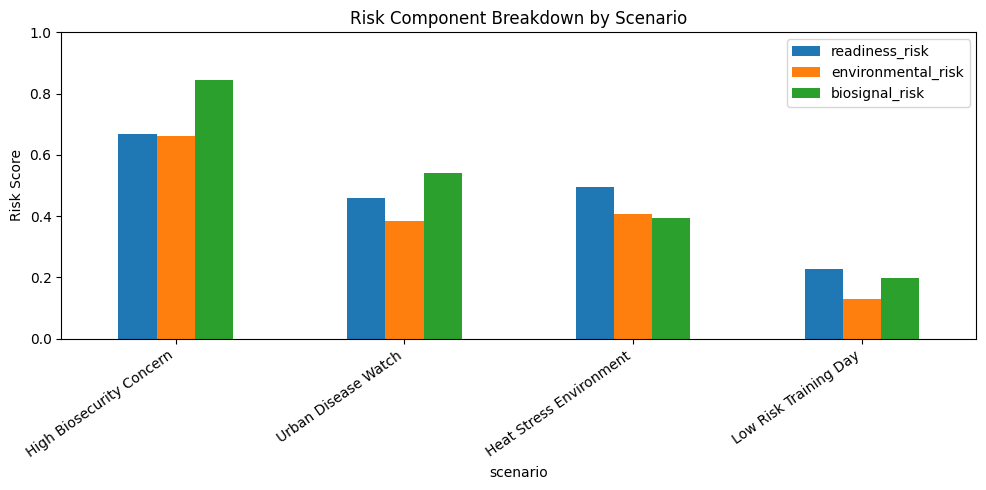

In [12]:
component_df = scenario_results.set_index("scenario")[
    ["readiness_risk", "environmental_risk", "biosignal_risk"]
]

component_df.plot(kind="bar", figsize=(10, 5))

plt.title("Risk Component Breakdown by Scenario")
plt.ylabel("Risk Score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [13]:
def executive_operational_report(sample, name="Operational Scenario"):
    status, explanation = operational_predict(sample)
    risks = explanation["risk_components"]

    print("=" * 75)
    print(f"OPERATIONAL BIOSECURITY & READINESS EXECUTIVE REPORT — {name}")
    print("=" * 75)
    print()
    print(f"Location: {sample['location']}")
    print(f"Operational Status: {status}")
    print(f"Overall Risk Score: {risks['overall_risk']:.1%}")
    print()
    print("Risk Component Breakdown:")
    print(f"- Readiness Risk: {risks['readiness_risk']:.1%}")
    print(f"- Environmental Risk: {risks['environmental_risk']:.1%}")
    print(f"- Biosignal Risk: {risks['biosignal_risk']:.1%}")
    print()
    print("Recommendation:")
    print(explanation["recommendation"])
    print()
    print("Key Drivers:")
    for bullet in explanation["bullets"]:
        print(f" - {bullet}")

    component_values = {
        "Readiness Risk": risks["readiness_risk"],
        "Environmental Risk": risks["environmental_risk"],
        "Biosignal Risk": risks["biosignal_risk"],
        "Overall Risk": risks["overall_risk"],
    }

    plt.figure(figsize=(8, 4))
    plt.bar(component_values.keys(), component_values.values())
    plt.title(f"Risk Profile — {name}")
    plt.ylabel("Risk Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

OPERATIONAL BIOSECURITY & READINESS EXECUTIVE REPORT — High Biosecurity Concern

Location: Miami, FL
Operational Status: MITIGATE
Overall Risk Score: 72.8%

Risk Component Breakdown:
- Readiness Risk: 66.9%
- Environmental Risk: 66.0%
- Biosignal Risk: 84.6%

Recommendation:
Reduce operational load, address key risk drivers, and increase monitoring.

Key Drivers:
 - Low sleep is increasing readiness risk.
 - High stress is reducing operational readiness.
 - Low hydration may impair performance.
 - High training load may require recovery planning.
 - Cognitive fatigue is elevated.
 - High temperature is increasing environmental burden.
 - High humidity may worsen heat stress.
 - Air quality is a notable environmental risk factor.
 - Local disease trend is elevated.
 - Biosignal anomaly is elevated.
 - Detection confidence suggests the biosignal should be taken seriously.
 - Signal persistence indicates the issue may not be temporary.


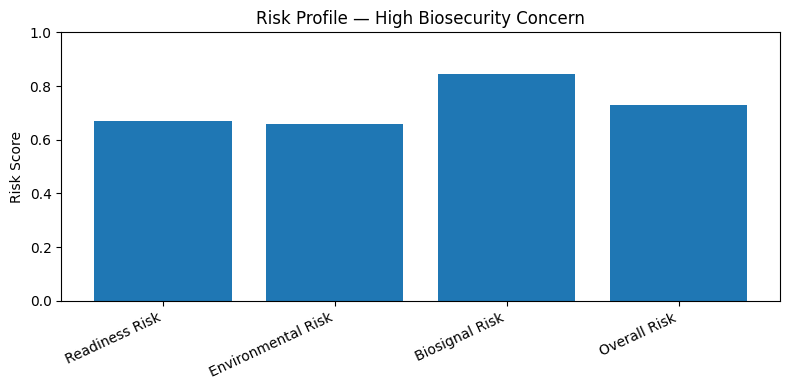

In [14]:
executive_operational_report(
    operational_scenarios["High Biosecurity Concern"],
    name="High Biosecurity Concern"
)

In [15]:
scenario_results.to_csv("operational_biosecurity_readiness_report.csv", index=False)

print("Saved report: operational_biosecurity_readiness_report.csv")

Saved report: operational_biosecurity_readiness_report.csv


In [16]:
artifact = {
    "model": model,
    "feature_cols": feature_cols,
    "classes": list(model.classes_),
}

joblib.dump(artifact, "operational_biosecurity_readiness_ai_v1.pkl")

print("Saved model artifact: operational_biosecurity_readiness_ai_v1.pkl")

Saved model artifact: operational_biosecurity_readiness_ai_v1.pkl


In [17]:
print("OPERATIONAL BIOSECURITY & READINESS AI v1 — PROJECT SUMMARY")
print("=" * 70)
print()
print("Purpose:")
print("This project combines human readiness, environmental context, geographic signals, and biosignal indicators to estimate operational biosecurity and readiness risk.")
print()
print("Model:")
print("- RandomForestClassifier")
print("- Multi-class prediction: READY / MONITOR / MITIGATE / RECOVER")
print()
print("Signal Groups:")
print("- Human readiness: sleep, stress, hydration, training load, cognitive fatigue")
print("- Environmental/geographic context: temperature, humidity, air quality, population density, disease trend, location")
print("- Biosignal risk: anomaly score, detection confidence, signal persistence")
print()
print("Current Capabilities:")
print("- Synthetic operational dataset generation")
print("- Risk component calculation")
print("- Operational status classification")
print("- Feature importance visualization")
print("- Scenario risk ranking")
print("- Risk component comparison")
print("- Executive operational report")
print("- Model artifact export")
print()
print("Portfolio Alignment:")
print("This capstone connects my prior applied AI projects across decision intelligence, biosecurity, human performance readiness, and biotechnology analytics.")
print()
print("Next Steps:")
print("- Build a Streamlit dashboard")
print("- Add real public environmental or disease surveillance datasets")
print("- Add time-series tracking")
print("- Add geographic mapping")
print("- Improve explainability")
print("- Compare multiple machine learning models")

OPERATIONAL BIOSECURITY & READINESS AI v1 — PROJECT SUMMARY

Purpose:
This project combines human readiness, environmental context, geographic signals, and biosignal indicators to estimate operational biosecurity and readiness risk.

Model:
- RandomForestClassifier
- Multi-class prediction: READY / MONITOR / MITIGATE / RECOVER

Signal Groups:
- Human readiness: sleep, stress, hydration, training load, cognitive fatigue
- Environmental/geographic context: temperature, humidity, air quality, population density, disease trend, location
- Biosignal risk: anomaly score, detection confidence, signal persistence

Current Capabilities:
- Synthetic operational dataset generation
- Risk component calculation
- Operational status classification
- Feature importance visualization
- Scenario risk ranking
- Risk component comparison
- Executive operational report
- Model artifact export

Portfolio Alignment:
This capstone connects my prior applied AI projects across decision intelligence, biosecurit